## Practice: Fun with Word Embeddings (4 points total)

Today we gonna play with word embeddings: train our own little embeddings, load one from the gensim model zoo and use it to visualize text corpora.

This whole thing is gonna happen on top of an embedding dataset.

__Requirements:__  `pip install --upgrade nltk gensim bokeh`, but only if you're running locally.

**Please submit this notebook as part of your homework!**

In [ ]:
!pip install gensim

In [ ]:
# download the data:
!wget https://www.dropbox.com/s/obaitrix9jyu84r/quora.txt?dl=1 -O ./quora.txt
# alternative download link: https://yadi.sk/i/BPQrUu1NaTduEw

In [1]:
import numpy as np

with open("./quora.txt", encoding="utf-8") as file:
    data = list(file)

data[50]

"What TV shows or books help you read people's body language?\n"

__Tokenization:__ a typical first step for an NLP task is to split raw data into words.
The text we're working with is in raw format: with all the punctuation and emojis attached to some words, so a simple str.split won't do.

Let's use __`nltk`__ - a library that handles many NLP tasks like tokenization, stemming, or part-of-speech tagging.

In [2]:
from nltk.tokenize import WordPunctTokenizer
tokenizer = WordPunctTokenizer()

print(tokenizer.tokenize(data[50]))

['What', 'TV', 'shows', 'or', 'books', 'help', 'you', 'read', 'people', "'", 's', 'body', 'language', '?']


In [3]:
# TASK: lowercase everything and extract tokens with tokenizer.
# data_tok should be a list of lists of tokens for each line in data.

data_tok = [tokenizer.tokenize(d.lower()) for d in data]

In [4]:
assert all(isinstance(row, (list, tuple)) for row in data_tok), "please convert each line into a list of tokens (strings)"
assert all(all(isinstance(tok, str) for tok in row) for row in data_tok), "please convert each line into a list of tokens (strings)"
is_latin = lambda tok: all('a' <= x.lower() <= 'z' for x in tok)
assert all(map(lambda l: not is_latin(l) or l.islower(), map(' '.join, data_tok))), "please make sure to lowercase the data"

In [5]:
print([' '.join(row) for row in data_tok[:2]])

["can i get back with my ex even though she is pregnant with another guy ' s baby ?", 'what are some ways to overcome a fast food addiction ?']


__Word vectors:__ as the saying goes, there's more than one way to train word embeddings. There's Word2Vec and GloVe with different objective functions. Then there's fastText that uses character-level models to train word embeddings.

The choice is huge, so let's start someplace small: __gensim__ is another NLP library that features many vector-based models including word2vec.

In [6]:
from gensim.models import Word2Vec

model = Word2Vec(data_tok,
                 vector_size=32,      # embedding vector size
                 min_count=5,         # consider words that occurred at least 5 times
                 window=5).wv         # define context as a 5-word window around the target word

# From gensim docs
# wv: This object essentially contains the mapping between words and embeddings.
# After training, it can be used directly to query those embeddings in various ways.

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [7]:
# now you can get word vectors !
model.get_vector('anything')

array([-2.915467  ,  2.8375394 ,  0.34022555,  0.8055711 ,  2.1838233 ,
        3.1490061 ,  0.6915839 , -4.0775127 ,  0.40326717,  3.4373417 ,
       -2.9095442 ,  2.7350688 ,  3.6154742 ,  1.1638896 ,  2.6959805 ,
       -1.2505646 , -0.86098313,  0.07308676,  1.1386267 , -0.6945222 ,
       -0.86224777,  0.06870867, -0.06989691, -2.1245358 , -0.33828577,
       -3.8129714 , -0.50481415,  1.326124  ,  1.0304171 ,  1.5179384 ,
       -1.9200566 , -0.92547417], dtype=float32)

In [8]:
(model.get_vector("cat") * model.get_vector("dog")).sum() / (model.get_vector("cat")**2).sum()**0.5 / (model.get_vector("dog")**2).sum()**0.5

np.float32(0.49171954)

In [9]:
model.most_similar('cat')

[('bitsat', 0.8244348168373108),
 ('aipmt', 0.8036467432975769),
 ('gre', 0.7988052368164062),
 ('ielts', 0.7896264791488647),
 ('xat', 0.7883118987083435),
 ('gmat', 0.782656192779541),
 ('jee', 0.78029465675354),
 ('sat', 0.7712234854698181),
 ('toefl', 0.7686567306518555),
 ('percentile', 0.7607323527336121)]

In [10]:
# or query similar words directly. Go play with it!
model.most_similar('bread')

[('rice', 0.9523214101791382),
 ('beans', 0.9436367750167847),
 ('cheese', 0.9363322257995605),
 ('sauce', 0.9301728010177612),
 ('butter', 0.9244480133056641),
 ('banana', 0.9174519181251526),
 ('corn', 0.9157087206840515),
 ('vodka', 0.9144970178604126),
 ('noodles', 0.9142752885818481),
 ('potato', 0.9141839146614075)]

### Using pre-trained model

Took it a while, huh? Now imagine training life-sized (100~300D) word embeddings on gigabytes of text: Wikipedia articles or Twitter posts.

Thankfully, nowadays you can get a pre-trained word embedding model in 2 lines of code (no SMS required, promise).

After being downloaded for the first time (or if you manually delete it), the model is saved in the `~/gensim_data` or `%USER_PATH%/gensim_data` directory. This can be checked by setting the return_path parameter to True.

In [12]:
import gensim.downloader as api
model = api.load('glove-twitter-100')

[==================================================] 100.0% 387.1/387.1MB downloaded


In [13]:
model.most_similar(positive=["coder", "money"], negative=["brain"])

[('broker', 0.5820155739784241),
 ('bonuses', 0.5424473285675049),
 ('banker', 0.5385112762451172),
 ('designer', 0.5197197794914246),
 ('merchandising', 0.4964233338832855),
 ('treet', 0.49220192432403564),
 ('shopper', 0.4920561909675598),
 ('part-time', 0.49128279089927673),
 ('freelance', 0.4843311905860901),
 ('aupair', 0.4796452522277832)]

```

```

```

```

```

```

```

```


# Visualizing data with word embeddings (1 point)

One way to see if our vectors are any good is to plot them. Thing is, those vectors are in 30D+ space and we humans are more used to 2-3D.

Luckily, we machine learners know about __dimensionality reduction__ methods.

Let's use that to plot 1000 most frequent words

In [14]:
words = model.index_to_key[:1000]

print(words[::100])

['<user>', '_', 'please', 'apa', 'justin', 'text', 'hari', 'playing', 'once', 'sei']


In [15]:
model.get_vector(words[0])

array([ 0.63006  ,  0.65177  ,  0.25545  ,  0.018593 ,  0.043094 ,
        0.047194 ,  0.23218  ,  0.11613  ,  0.17371  ,  0.40487  ,
        0.022524 , -0.076731 , -2.2911   ,  0.094127 ,  0.43293  ,
        0.041801 ,  0.063175 , -0.64486  , -0.43657  ,  0.024114 ,
       -0.082989 ,  0.21686  , -0.13462  , -0.22336  ,  0.39436  ,
       -2.1724   , -0.39544  ,  0.16536  ,  0.39438  , -0.35182  ,
       -0.14996  ,  0.10502  , -0.45937  ,  0.27729  ,  0.8924   ,
       -0.042313 , -0.009345 ,  0.55017  ,  0.095521 ,  0.070504 ,
       -1.1781   ,  0.013723 ,  0.17742  ,  0.74142  ,  0.17716  ,
        0.038468 , -0.31684  ,  0.08941  ,  0.20557  , -0.34328  ,
       -0.64303  , -0.878    , -0.16293  , -0.055925 ,  0.33898  ,
        0.60664  , -0.2774   ,  0.33626  ,  0.21603  , -0.11051  ,
        0.0058673, -0.64757  , -0.068222 , -0.77414  ,  0.13911  ,
       -0.15851  , -0.61885  , -0.10192  , -0.47     ,  0.19787  ,
        0.42175  , -0.18458  ,  0.080581 , -0.22545  , -0.0651

In [16]:
# for each word, compute its vector with model
word_vectors = np.array([model.get_vector(d) for d in words])  # YOUR CODE
word_vectors

array([[ 0.63006 ,  0.65177 ,  0.25545 , ...,  0.55096 ,  0.64706 ,
        -0.6093  ],
       [ 0.18205 , -0.048483,  0.23966 , ..., -0.3358  ,  0.18884 ,
        -0.40786 ],
       [ 1.0674  ,  0.45716 ,  0.51463 , ...,  0.13974 ,  0.76487 ,
        -0.17314 ],
       ...,
       [ 0.11065 , -0.040876,  0.2586  , ..., -0.74773 ,  0.306   ,
         0.37911 ],
       [ 0.30491 , -0.89558 , -0.46538 , ...,  0.73649 ,  1.3842  ,
         0.99976 ],
       [-0.43051 ,  0.56302 ,  0.38305 , ..., -0.3222  ,  0.32782 ,
         0.51519 ]], shape=(1000, 100), dtype=float32)

In [17]:
assert isinstance(word_vectors, np.ndarray)
assert word_vectors.shape == (len(words), 100)
assert np.isfinite(word_vectors).all()

#### Linear projection: PCA

The simplest linear dimensionality reduction method is **P**rincipal **C**omponent **A**nalysis.

In geometric terms, PCA tries to find axes along which most of the variance occurs. The "natural" axes, if you wish.

<img src="https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/pca_fish.png" style="width:30%">


Under the hood, it attempts to decompose object-feature matrix $X$ into two smaller matrices: $W$ and $\hat W$ minimizing _mean squared error_:

$$\|(X W) \hat{W} - X\|^2_2 \to_{W, \hat{W}} \min$$
- $X \in \mathbb{R}^{n \times m}$ - object matrix (**centered**);
- $W \in \mathbb{R}^{m \times d}$ - matrix of direct transformation;
- $\hat{W} \in \mathbb{R}^{d \times m}$ - matrix of reverse transformation;
- $n$ samples, $m$ original dimensions and $d$ target dimensions;



In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# map word vectors onto 2d plane with PCA. Use good old sklearn API (fit, transform)
# after that, normalize vectors to make sure they have zero mean and unit variance

word_vectors_pca = PCA(n_components=2).fit_transform(word_vectors)  
scaler = StandardScaler()
word_vectors_pca = scaler.fit_transform(word_vectors_pca)


In [20]:
assert word_vectors_pca.shape == (len(word_vectors), 2), "there must be a 2d vector for each word"
assert max(abs(word_vectors_pca.mean(0))) < 1e-5, "points must be zero-centered"
assert max(abs(1.0 - word_vectors_pca.std(0))) < 1e-2, "points must have unit variance"

#### Let's draw it!

In [22]:
import bokeh.models as bm, bokeh.plotting as pl
from bokeh.io import output_notebook
output_notebook()

def draw_vectors(x, y, radius=10, alpha=0.25, color='blue',
                 width=600, height=400, show=True, **kwargs):
    """ draws an interactive plot for data points with auxilirary info on hover """
    if isinstance(color, str): color = [color] * len(x)
    data_source = bm.ColumnDataSource({ 'x' : x, 'y' : y, 'color': color, **kwargs })

    fig = pl.figure(active_scroll='wheel_zoom', width=width, height=height)
    fig.scatter('x', 'y', size=radius, color='color', alpha=alpha, source=data_source)

    fig.add_tools(bm.HoverTool(tooltips=[(key, "@" + key) for key in kwargs.keys()]))
    if show: pl.show(fig)
    return fig

Loading BokehJS ...

In [23]:
draw_vectors(word_vectors_pca[:, 0], word_vectors_pca[:, 1], token=words)

# hover a mouse over there and see if you can identify the clusters

figure(id='p1011', ...)

#### Visualizing neighbors with t-SNE
PCA is nice but it's strictly linear and thus only able to capture coarse high-level structure of the data.

If we instead want to focus on keeping neighboring points near, we could use TSNE, which is itself an embedding method. Here you can read __[more on TSNE](https://distill.pub/2016/misread-tsne/)__.

In [24]:
from sklearn.manifold import TSNE

# map word vectors onto 2d plane with TSNE. hint: don't panic, it may take a minute or two to fit.
# normalize them as just like with PCA


word_tsne = TSNE(2).fit_transform(word_vectors)
word_tsne = scaler.fit_transform(word_tsne)
word_tsne

array([[ 0.38011673,  0.8478987 ],
       [ 0.4538817 ,  0.87344855],
       [ 0.3669139 ,  0.81004065],
       ...,
       [ 1.5810823 , -1.361328  ],
       [-0.5875736 ,  1.2357167 ],
       [-0.7337552 , -1.1446078 ]], shape=(1000, 2), dtype=float32)

In [25]:
draw_vectors(x=word_tsne[:, 0], y=word_tsne[:, 1], color='green', token=words)

figure(id='p1061', ...)

### Visualizing phrases

Word embeddings can also be used to represent short phrases. The simplest way is to take __an average__ of vectors for all tokens in the phrase with some weights.

This trick is useful to identify what data are you working with: find if there are any outliers, clusters or other artifacts.

Let's try this new hammer on our data!


In [35]:

def get_phrase_embedding(phrase):
    """
    Convert phrase to a vector by aggregating it's word embeddings. See description above.
    """
    # 1. lowercase phrase
    # 2. tokenize phrase
    # 3. average word vectors for all words in tokenized phrase
    # skip words that are not in model's vocabulary
    # if all words are missing from vocabulary, return zeros

    vector = np.zeros([model.vector_size], dtype='float32')

    phrase = phrase.lower()
    phrase = tokenizer.tokenize(phrase)
    vector = np.array([model.get_vector(word) for word in phrase if word in model])
    if len(vector) == 0:
        return np.zeros([model.vector_size], dtype="float32")
    
    return np.mean(vector, axis=0)



In [36]:
vector = get_phrase_embedding("I'm very sure. This never happened to me before...")

assert np.allclose(vector[::10],
                   np.array([ 0.31807372, -0.02558171,  0.0933293 , -0.1002182 , -1.0278689 ,
                             -0.16621883,  0.05083408,  0.17989802,  1.3701859 ,  0.08655966],
                              dtype=np.float32))
assert np.array_equal(get_phrase_embedding("thisisgibberish"), np.zeros([model.vector_size], dtype='float32')), "corner case for all missing words should be handled as described in the function comments"

In [43]:
# let's only consider ~5k phrases for a first run.
chosen_phrases = data[::len(data) // 1000]

# compute vectors for chosen phrases
phrase_vectors = np.array([get_phrase_embedding(phrase) for phrase in chosen_phrases])

SyntaxError: invalid syntax (3800537467.py, line 1)

In [45]:
assert isinstance(phrase_vectors, np.ndarray) and np.isfinite(phrase_vectors).all()
assert phrase_vectors.shape == (len(chosen_phrases), model.vector_size)

In [46]:
# map vectors into 2d space with pca, tsne or your other method of choice
# don't forget to normalize

phrase_vectors_2d = TSNE(2).fit_transform(phrase_vectors)

phrase_vectors_2d = (phrase_vectors_2d - phrase_vectors_2d.mean(axis=0)) / phrase_vectors_2d.std(axis=0)

In [47]:
draw_vectors(phrase_vectors_2d[:, 0], phrase_vectors_2d[:, 1],
             phrase=[phrase[:50] for phrase in chosen_phrases],
             radius=20,)

figure(id='p1111', ...)

**There's more below! Scroll down when you're ready.**
```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```


### Text Classification: Prohibited Comment Classification

![img](https://github.com/yandexdataschool/nlp_course/raw/master/resources/banhammer.jpg)

__In this notebook__ you will build an algorithm that classifies social media comments into normal or toxic.
Like in many real-world cases, you only have a small (10^3) dataset of hand-labeled examples to work with. We'll tackle this problem using both classical nlp methods and embedding-based approach.

In [48]:
# if you're in colab, download the data:
#!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/refs/heads/2025/week01_embeddings/comments.tsv -O ./comments.tsv -q

zsh:1: command not found: wget


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
data = pd.read_csv("comments.tsv", sep='\t')

texts = data['comment_text'].values
target = data['should_ban'].values
data[50::200]

,should_ban,comment_text
50,0,"""Those who're in advantageous positions are th..."
250,1,Fartsalot56 says f**k you motherclucker!!
450,1,"Are you a fool? \n\nI am sorry, but you seem t..."
650,1,I AM NOT A VANDAL!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
850,0,Citing sources\n\nCheck out the Wikipedia:Citi...


In [50]:
from sklearn.model_selection import train_test_split
texts_train, texts_test, y_train, y_test = train_test_split(texts, target, test_size=0.5, random_state=42)

__Note:__ it is generally a good idea to split data into train/test before anything is done to them.

It guards you against possible data leakage in the preprocessing stage. For example, should you decide to select words present in obscene tweets as features, you should only count those words over the training set. Otherwise your algoritm can cheat evaluation.

### Preprocessing and tokenization

Comments contain raw text with punctuation, upper/lowercase letters and even newline symbols.

To simplify all further steps, we'll split text into space-separated tokens using one of nltk tokenizers.

In [51]:
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()
preprocess = lambda text: ' '.join(tokenizer.tokenize(text.lower()))

text = 'How to be a grown-up at work: replace "fuck you" with "Ok, great!".'
print("before:", text,)
print("after:", preprocess(text),)

before: How to be a grown-up at work: replace "fuck you" with "Ok, great!".
after: how to be a grown-up at work : replace " fuck you " with " ok , great ! " .


In [53]:
# task: preprocess each comment in train and test

texts_train = np.array([preprocess(text) for text in texts_train])
texts_test = np.array([preprocess(text) for text in texts_test])  

In [54]:
assert texts_train[5] ==  'who cares anymore . they attack with impunity .'
assert texts_test[89] == 'hey todds ! quick q ? why are you so gay'
assert len(texts_test) == len(y_test)

### Solving it: bag of words (1 point)

![img](http://www.novuslight.com/uploads/n/BagofWords.jpg)

One traditional approach to such problem is to use bag of words features:
1. build a vocabulary of frequent words (use train data only)
2. for each training sample, count the number of times a word occurs in it (for each word in vocabulary).
3. consider this count a feature for some classifier

__Note:__ in practice, you can compute such features using sklearn. Please don't do that in the current assignment, though.
* `from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer`

In [57]:
from collections import Counter
cnt = Counter()
for phrase in texts_train:
    for word in phrase.split():
        cnt[word] += 1

cnt.most_common(3)

[('.', 1513), (',', 1389), ('you', 1342)]

In [65]:
# task: find up to k most frequent tokens in texts_train,
# sort them by number of occurrences (highest first)
k = 10000

cnt = Counter()
for phrase in texts_train:
    for word in phrase.split():
        cnt[word] += 1

bow_vocabulary = [word for word, _ in cnt.most_common(k)]

print('example features:', sorted(bow_vocabulary)[::100])

example features: ['!', '12:20', '300', '_', 'adorned', 'alternative', 'archive', 'average', 'benkner', 'bout', 'came', 'chest', 'combined', 'consumers', 'cricket', 'decisions', 'dickheads', 'domestic', 'eductaion', 'essentially', 'faggot', 'firms', 'frustrated', 'goal', 'hanibal', 'hip-hop', 'identified', 'infoboxes', 'issue', 'kindergarten', 'lets', 'lot', "mclaren's", 'moderator', 'naturally', 'noticeable', 'opposing', 'pdf', 'plant', 'pretoria', 'punctuation', 'rebels', 'repetative', 'riadh', 'schulz', 'shes', 'slit', 'spoof', 'stupid', 't', 'theoretical', 'topic', 'uglyness', 'userspace', 'wanted', 'wikieditor', 'year', '←']


In [66]:
def text_to_bow(text):
    """ convert text string to an array of token counts. Use bow_vocabulary. """
    vector = np.zeros(len(bow_vocabulary), dtype="float32")
    cnt = Counter(text.split())
   
    for i, word in enumerate(bow_vocabulary):
        vector[i] = cnt[word]

    return vector

In [67]:
X_train_bow = np.stack(list(map(text_to_bow, texts_train)))
X_test_bow = np.stack(list(map(text_to_bow, texts_test)))

In [68]:
k_max = len(set(' '.join(texts_train).split()))
assert X_train_bow.shape == (len(texts_train), min(k, k_max))
assert X_test_bow.shape == (len(texts_test), min(k, k_max))
assert np.all(X_train_bow[5:10].sum(-1) == np.array([len(s.split()) for s in  texts_train[5:10]]))
assert len(bow_vocabulary) <= min(k, k_max)
assert X_train_bow[6, bow_vocabulary.index('.')] == texts_train[6].split().count('.')

In [69]:
X_train_bow

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 9.,  3.,  1., ...,  0.,  0.,  0.],
       [ 1.,  0.,  1., ...,  0.,  0.,  0.],
       ...,
       [ 4.,  5.,  1., ...,  1.,  0.,  0.],
       [35., 35., 35., ...,  0.,  0.,  0.],
       [ 2.,  1.,  0., ...,  0.,  1.,  1.]],
      shape=(500, 5707), dtype=float32)

We shall use a simple linear model: __Logistic Regression__.
It might not be the fanciest one around, but the simplicity has its own advantages: a linear model is blazingly fast and needs less data to fit.
Let's sklearn it!

In [103]:
from sklearn.linear_model import LogisticRegression
bow_model = LogisticRegression(C=0.243234, max_iter=10000)  # YOUR CODE HERE - train a logistic regression
bow_model.fit(X_train_bow, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.243234
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [106]:
import optuna

def objective(trial):
    # model parameters
    params = {
        "C" : trial.suggest_float("C", 1e-5, 1e5, log=True),
        "solver" : trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
        "max_iter" : 10000
    }
    model = LogisticRegression(**params)
    model.fit(X_train_bow, y_train)
    test_accuracy = np.mean(bow_model.predict(X_test_bow) == y_test)
    
    return test_accuracy

study = optuna.create_study(direction="maximize")
study.optimize(objective, show_progress_bar=True, n_trials=200)

[I 2026-03-25 11:56:40,579] A new study created in memory with name: no-name-752156f8-b6a1-424a-b731-b7b094db6817
Best trial: 0. Best value: 0.77:   3%|▎         | 6/200 [00:00<00:08, 23.38it/s]

[I 2026-03-25 11:56:40,603] Trial 0 finished with value: 0.77 and parameters: {'C': 1.6634666496286e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,618] Trial 1 finished with value: 0.77 and parameters: {'C': 7258.078851310202, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,674] Trial 2 finished with value: 0.77 and parameters: {'C': 308.86905162044013, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,750] Trial 3 finished with value: 0.77 and parameters: {'C': 0.17260367829623358, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,761] Trial 4 finished with value: 0.77 and parameters: {'C': 0.5911279410211214, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,768] Trial 5 finished with value: 0.77 and parameters: {'C': 0.0004564140625629782, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,794] Trial 6 

Best trial: 0. Best value: 0.77:   8%|▊         | 16/200 [00:00<00:06, 28.13it/s]

[I 2026-03-25 11:56:40,869] Trial 7 finished with value: 0.77 and parameters: {'C': 1.277162197906545, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,895] Trial 8 finished with value: 0.77 and parameters: {'C': 0.00011451499408142065, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,970] Trial 9 finished with value: 0.77 and parameters: {'C': 137.1217504257916, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,978] Trial 10 finished with value: 0.77 and parameters: {'C': 2.422095370708134e-05, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:40,993] Trial 11 finished with value: 0.77 and parameters: {'C': 59140.04044267078, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,002] Trial 12 finished with value: 0.77 and parameters: {'C': 0.011415434970819899, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,015] Tri

Best trial: 0. Best value: 0.77:  12%|█▏        | 24/200 [00:00<00:04, 39.81it/s]

[I 2026-03-25 11:56:41,109] Trial 17 finished with value: 0.77 and parameters: {'C': 7.713709669918438, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,134] Trial 18 finished with value: 0.77 and parameters: {'C': 6564.723428132111, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,147] Trial 19 finished with value: 0.77 and parameters: {'C': 17.37260544999077, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,167] Trial 20 finished with value: 0.77 and parameters: {'C': 0.0024684816872240973, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,205] Trial 21 finished with value: 0.77 and parameters: {'C': 397.4354673169235, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,227] Trial 22 finished with value: 0.77 and parameters: {'C': 6763.080745459831, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,283] Trial 23 finishe

Best trial: 0. Best value: 0.77:  16%|█▌        | 31/200 [00:00<00:04, 34.75it/s]

[I 2026-03-25 11:56:41,328] Trial 25 finished with value: 0.77 and parameters: {'C': 1649.644908640284, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,342] Trial 26 finished with value: 0.77 and parameters: {'C': 96.90771546378141, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,374] Trial 27 finished with value: 0.77 and parameters: {'C': 82745.42322529871, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,388] Trial 28 finished with value: 0.77 and parameters: {'C': 4.263250685129232, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,441] Trial 29 finished with value: 0.77 and parameters: {'C': 0.15780620826285333, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,482] Trial 30 finished with value: 0.77 and parameters: {'C': 602.904461745515, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,525] Trial 31 finish

Best trial: 0. Best value: 0.77:  20%|█▉        | 39/200 [00:01<00:04, 33.34it/s]

[I 2026-03-25 11:56:41,547] Trial 32 finished with value: 0.77 and parameters: {'C': 1.2991624005927742e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,606] Trial 33 finished with value: 0.77 and parameters: {'C': 0.6834831886210521, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,612] Trial 34 finished with value: 0.77 and parameters: {'C': 0.00010589173672799397, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,644] Trial 35 finished with value: 0.77 and parameters: {'C': 0.009531039927185068, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,657] Trial 36 finished with value: 0.77 and parameters: {'C': 0.0002131860886517904, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,720] Trial 37 finished with value: 0.77 and parameters: {'C': 38.45453473816696, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,733] Tr

Best trial: 0. Best value: 0.77:  24%|██▍       | 49/200 [00:01<00:03, 45.24it/s]

[I 2026-03-25 11:56:41,756] Trial 39 finished with value: 0.77 and parameters: {'C': 1718.9918066706073, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,772] Trial 40 finished with value: 0.77 and parameters: {'C': 306.10476594984704, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,783] Trial 41 finished with value: 0.77 and parameters: {'C': 0.593023971103893, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,798] Trial 42 finished with value: 0.77 and parameters: {'C': 23149.558991754468, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,807] Trial 43 finished with value: 0.77 and parameters: {'C': 0.06206255202478608, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,814] Trial 44 finished with value: 0.77 and parameters: {'C': 0.0013073469809395091, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,

Best trial: 0. Best value: 0.77:  30%|███       | 61/200 [00:01<00:02, 47.91it/s]

[I 2026-03-25 11:56:41,985] Trial 50 finished with value: 0.77 and parameters: {'C': 0.025792258697539875, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,991] Trial 51 finished with value: 0.77 and parameters: {'C': 5.641855918994586e-05, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:41,999] Trial 52 finished with value: 0.77 and parameters: {'C': 0.00033397021925088405, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,006] Trial 53 finished with value: 0.77 and parameters: {'C': 3.70935868768691e-05, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,016] Trial 54 finished with value: 0.77 and parameters: {'C': 0.0012060916628271277, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,025] Trial 55 finished with value: 0.77 and parameters: {'C': 0.0051336031484965836, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-0

Best trial: 0. Best value: 0.77:  33%|███▎      | 66/200 [00:01<00:03, 39.49it/s]

[I 2026-03-25 11:56:42,205] Trial 62 finished with value: 0.77 and parameters: {'C': 206.7126498099241, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,237] Trial 63 finished with value: 0.77 and parameters: {'C': 815.4977111927168, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,301] Trial 64 finished with value: 0.77 and parameters: {'C': 7.680379698987585, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,363] Trial 65 finished with value: 0.77 and parameters: {'C': 63.696131321125605, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,386] Trial 66 finished with value: 0.77 and parameters: {'C': 1087.6593247472013, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.


Best trial: 0. Best value: 0.77:  36%|███▋      | 73/200 [00:02<00:03, 37.80it/s]

[I 2026-03-25 11:56:42,410] Trial 67 finished with value: 0.77 and parameters: {'C': 11844.720177857394, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,423] Trial 68 finished with value: 0.77 and parameters: {'C': 44756.92038663717, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,448] Trial 69 finished with value: 0.77 and parameters: {'C': 2769.8608513329086, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,455] Trial 70 finished with value: 0.77 and parameters: {'C': 0.00011710213457337029, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,501] Trial 71 finished with value: 0.77 and parameters: {'C': 0.3489060387536666, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,556] Trial 72 finished with value: 0.77 and parameters: {'C': 12.206769823111227, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,581] Trial 7

Best trial: 0. Best value: 0.77:  40%|████      | 81/200 [00:02<00:03, 33.35it/s]

[I 2026-03-25 11:56:42,624] Trial 74 finished with value: 0.77 and parameters: {'C': 196.38081412036533, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,659] Trial 75 finished with value: 0.77 and parameters: {'C': 2.2359585242780416e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,708] Trial 76 finished with value: 0.77 and parameters: {'C': 0.12094171000355505, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,719] Trial 77 finished with value: 0.77 and parameters: {'C': 0.704673161091052, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,758] Trial 78 finished with value: 0.77 and parameters: {'C': 362.34184554813186, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,770] Trial 79 finished with value: 0.77 and parameters: {'C': 3.7534392226933737, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,791] Trial 

Best trial: 0. Best value: 0.77:  46%|████▌     | 91/200 [00:02<00:02, 42.42it/s]

[I 2026-03-25 11:56:42,830] Trial 82 finished with value: 0.77 and parameters: {'C': 4.1314222667275004e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,864] Trial 83 finished with value: 0.77 and parameters: {'C': 2.2997864035911846e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,896] Trial 84 finished with value: 0.77 and parameters: {'C': 3871.5135620518963, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,904] Trial 85 finished with value: 0.77 and parameters: {'C': 0.02528643454683223, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,926] Trial 86 finished with value: 0.77 and parameters: {'C': 0.00054980737625399, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,933] Trial 87 finished with value: 0.77 and parameters: {'C': 0.00023148355109006848, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:42,9

Best trial: 0. Best value: 0.77:  48%|████▊     | 97/200 [00:02<00:03, 34.02it/s]

[I 2026-03-25 11:56:43,084] Trial 92 finished with value: 0.77 and parameters: {'C': 136.281104641825, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,133] Trial 93 finished with value: 0.77 and parameters: {'C': 0.3721607737949165, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,186] Trial 94 finished with value: 0.77 and parameters: {'C': 62.082970899852896, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,208] Trial 95 finished with value: 0.77 and parameters: {'C': 99271.55763786758, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,222] Trial 96 finished with value: 0.77 and parameters: {'C': 1428.309396445029, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,280] Trial 97 finished with value: 0.77 and parameters: {'C': 20.231449196581153, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.


Best trial: 0. Best value: 0.77:  55%|█████▌    | 110/200 [00:02<00:02, 44.93it/s]

[I 2026-03-25 11:56:43,287] Trial 98 finished with value: 0.77 and parameters: {'C': 0.0022428689660648642, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,306] Trial 99 finished with value: 0.77 and parameters: {'C': 1.4307582310035168e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,365] Trial 100 finished with value: 0.77 and parameters: {'C': 2.6883262390314515, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,371] Trial 101 finished with value: 0.77 and parameters: {'C': 2.3009922254248864e-05, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,377] Trial 102 finished with value: 0.77 and parameters: {'C': 6.727879697834163e-05, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,384] Trial 103 finished with value: 0.77 and parameters: {'C': 0.00017010763615548692, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-

Best trial: 0. Best value: 0.77:  59%|█████▉    | 118/200 [00:03<00:01, 44.86it/s]

[I 2026-03-25 11:56:43,495] Trial 110 finished with value: 0.77 and parameters: {'C': 754.5994619193292, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,509] Trial 111 finished with value: 0.77 and parameters: {'C': 36302.36556415465, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,524] Trial 112 finished with value: 0.77 and parameters: {'C': 12387.825237380412, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,539] Trial 113 finished with value: 0.77 and parameters: {'C': 234.8408850531267, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,554] Trial 114 finished with value: 0.77 and parameters: {'C': 19639.00046024479, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,568] Trial 115 finished with value: 0.77 and parameters: {'C': 406.1022065695758, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,62

Best trial: 0. Best value: 0.77:  64%|██████▍   | 129/200 [00:03<00:01, 43.27it/s]

[I 2026-03-25 11:56:43,735] Trial 119 finished with value: 0.77 and parameters: {'C': 0.08054179352407362, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,751] Trial 120 finished with value: 0.77 and parameters: {'C': 102.43240669557933, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,759] Trial 121 finished with value: 0.77 and parameters: {'C': 0.0004808960562236232, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,769] Trial 122 finished with value: 0.77 and parameters: {'C': 0.03145490398511522, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,782] Trial 123 finished with value: 0.77 and parameters: {'C': 0.7461833089890617, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,791] Trial 124 finished with value: 0.77 and parameters: {'C': 0.004883165174174355, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25

Best trial: 0. Best value: 0.77:  70%|███████   | 141/200 [00:03<00:01, 50.03it/s]

[I 2026-03-25 11:56:43,938] Trial 130 finished with value: 0.77 and parameters: {'C': 0.0002614930823404226, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,949] Trial 131 finished with value: 0.77 and parameters: {'C': 1.923030030741474, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,965] Trial 132 finished with value: 0.77 and parameters: {'C': 12.168168286188175, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,976] Trial 133 finished with value: 0.77 and parameters: {'C': 0.19168768949544074, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:43,988] Trial 134 finished with value: 0.77 and parameters: {'C': 1.0434885824072235, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,000] Trial 135 finished with value: 0.77 and parameters: {'C': 4.9474593174312504, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:

Best trial: 0. Best value: 0.77:  74%|███████▎  | 147/200 [00:03<00:01, 43.31it/s]

[I 2026-03-25 11:56:44,155] Trial 142 finished with value: 0.77 and parameters: {'C': 67199.5615975975, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,183] Trial 143 finished with value: 0.77 and parameters: {'C': 10838.452781036307, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,207] Trial 144 finished with value: 0.77 and parameters: {'C': 19789.402585969005, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,274] Trial 145 finished with value: 0.77 and parameters: {'C': 62.7523407776756, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,300] Trial 146 finished with value: 0.77 and parameters: {'C': 36619.00467592387, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,315] Trial 147 finished with value: 0.77 and parameters: {'C': 2018.726317847907, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.


Best trial: 0. Best value: 0.77:  80%|███████▉  | 159/200 [00:03<00:00, 44.89it/s]

[I 2026-03-25 11:56:44,369] Trial 148 finished with value: 0.77 and parameters: {'C': 0.1119758058311126, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,384] Trial 149 finished with value: 0.77 and parameters: {'C': 7157.328771885247, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,421] Trial 150 finished with value: 0.77 and parameters: {'C': 0.04747631119356663, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,429] Trial 151 finished with value: 0.77 and parameters: {'C': 0.00225032186084507, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,436] Trial 152 finished with value: 0.77 and parameters: {'C': 8.577090618433288e-05, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,443] Trial 153 finished with value: 0.77 and parameters: {'C': 0.0005694096437740361, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:

Best trial: 0. Best value: 0.77:  84%|████████▍ | 169/200 [00:04<00:00, 52.54it/s]

[I 2026-03-25 11:56:44,580] Trial 159 finished with value: 0.77 and parameters: {'C': 245.63556899680384, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,607] Trial 160 finished with value: 0.77 and parameters: {'C': 0.0032103080590020804, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,620] Trial 161 finished with value: 0.77 and parameters: {'C': 0.27123467937306167, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,631] Trial 162 finished with value: 0.77 and parameters: {'C': 0.07625654623729496, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,642] Trial 163 finished with value: 0.77 and parameters: {'C': 0.05018439426415, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,652] Trial 164 finished with value: 0.77 and parameters: {'C': 0.013308749892708787, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 1

Best trial: 0. Best value: 0.77:  86%|████████▋ | 173/200 [00:04<00:00, 35.75it/s]

[I 2026-03-25 11:56:44,790] Trial 170 finished with value: 0.77 and parameters: {'C': 95726.51660028989, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,883] Trial 171 finished with value: 0.77 and parameters: {'C': 19.89626627000193, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:44,981] Trial 172 finished with value: 0.77 and parameters: {'C': 8.22040337419735, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.


Best trial: 0. Best value: 0.77:  88%|████████▊ | 176/200 [00:04<00:00, 35.75it/s]

[I 2026-03-25 11:56:45,070] Trial 173 finished with value: 0.77 and parameters: {'C': 35.80161950256734, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,139] Trial 174 finished with value: 0.77 and parameters: {'C': 0.2728249787610776, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,199] Trial 175 finished with value: 0.77 and parameters: {'C': 0.979598699463982, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,260] Trial 176 finished with value: 0.77 and parameters: {'C': 3.0848415646071747, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.


Best trial: 0. Best value: 0.77:  92%|█████████▏| 184/200 [00:04<00:00, 29.40it/s]

[I 2026-03-25 11:56:45,275] Trial 177 finished with value: 0.77 and parameters: {'C': 102.65705703807564, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,298] Trial 178 finished with value: 0.77 and parameters: {'C': 1.5736657654156793e-05, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,310] Trial 179 finished with value: 0.77 and parameters: {'C': 0.4487028880858833, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,368] Trial 180 finished with value: 0.77 and parameters: {'C': 5.967564389405758, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,391] Trial 181 finished with value: 0.77 and parameters: {'C': 3040.3060351863405, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,414] Trial 182 finished with value: 0.77 and parameters: {'C': 5147.5600830122385, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,436] T

Best trial: 0. Best value: 0.77:  98%|█████████▊| 197/200 [00:05<00:00, 39.86it/s]

[I 2026-03-25 11:56:45,482] Trial 185 finished with value: 0.77 and parameters: {'C': 13253.749818366872, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,496] Trial 186 finished with value: 0.77 and parameters: {'C': 1062.3957538632108, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,517] Trial 187 finished with value: 0.77 and parameters: {'C': 0.001343155260767865, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,531] Trial 188 finished with value: 0.77 and parameters: {'C': 28653.511735042397, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,551] Trial 189 finished with value: 0.77 and parameters: {'C': 0.00018391759740150014, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,565] Trial 190 finished with value: 0.77 and parameters: {'C': 1999.4586759166482, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45

Best trial: 0. Best value: 0.77: 100%|██████████| 200/200 [00:05<00:00, 38.51it/s]

[I 2026-03-25 11:56:45,761] Trial 198 finished with value: 0.77 and parameters: {'C': 19.1868676154841, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.77.
[I 2026-03-25 11:56:45,773] Trial 199 finished with value: 0.77 and parameters: {'C': 1.6991435834276165, 'solver': 'liblinear'}. Best is trial 0 with value: 0.77.


Model accuracy: 0.770


AssertionError: Hint: tune the parameter C to improve performance

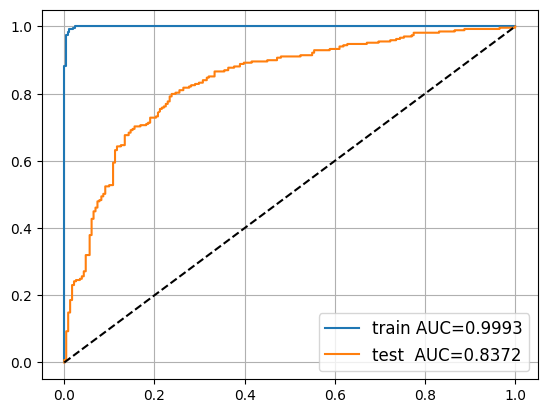

In [104]:
from sklearn.metrics import roc_auc_score, roc_curve

for name, X, y, model in [
    ('train', X_train_bow, y_train, bow_model),
    ('test ', X_test_bow, y_test, bow_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(bow_model.predict(X_test_bow) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.77, "Hint: tune the parameter C to improve performance"
print("Well done!")

### Task: implement TF-IDF features (1 point)

Not all words are equally useful. One can prioritize rare words and downscale words like "and"/"or" by using __tf-idf features__. This abbreviation stands for __text frequency/inverse document frequency__ and means exactly that:

$$ \text{feature}_i = \frac{\text{Count}(word_i \in x)}{\text{Total number of words in } x} \times \log\left(\frac{N}{\text{Count}(word_i \in D) + \alpha}\right) $$


, where x is a single text, D is your dataset (a collection of texts), N is a total number of documents and $\alpha$ is a smoothing hyperparameter (typically 1).
And $Count(word_i \in D)$ is the number of documents where $word_i$ appears.

It may also be a good idea to normalize each data sample after computing tf-idf features.

__Your task:__ implement tf-idf features, train a model and evaluate ROC curve. Compare it with basic BagOfWords model from above.

Please don't use sklearn/nltk built-in tf-idf vectorizers in your solution :) You can still use 'em for debugging though.

In [108]:
doc_counter = Counter()
for text in texts_train:
    for word in set(text.split()):
        doc_counter[word] += 1

In [119]:
def tf_idf(text, alpha=1):
    vector = np.zeros(len(bow_vocabulary), dtype="float32")
    counter = Counter(text.split())

    for i, word in enumerate(bow_vocabulary):
        vector[i] = (counter[word] / len(text.split())) * np.log(len(texts_train)/(doc_counter[word] + alpha))

    return vector

In [120]:
X_train_tfidf = np.stack(list(map(tf_idf, texts_train)))
X_test_tfidf = np.stack(list(map(tf_idf, texts_test)))

In [127]:
tfidf_model = LogisticRegression(C=0.43, max_iter=10000)
tfidf_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.43
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

Model accuracy: 0.780
Well done!


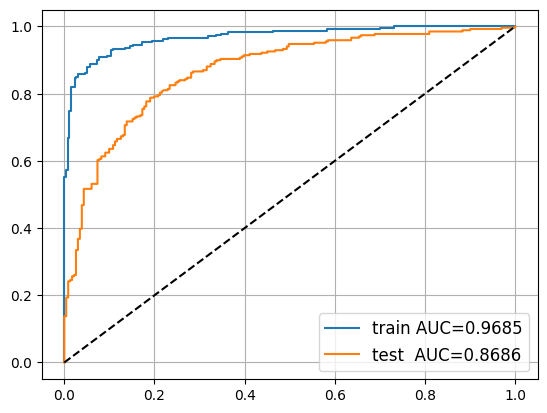

In [128]:
for name, X, y, model in [
    ('train', X_train_tfidf, y_train, tfidf_model),
    ('test ', X_test_tfidf, y_test, tfidf_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(tfidf_model.predict(X_test_bow) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.77, "Hint: tune the parameter C to improve performance"
print("Well done!")

Scroll down when you're done with TF-IDF!
```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```


### Solving it better: word vectors (1 point)

Let's try another approach: instead of counting per-word frequencies, we shall map all words to pre-trained word vectors and average over them to get text features.

This should give us two key advantages: (1) we now have 10^2 features instead of 10^4 and (2) our model can generalize to word that are not in training dataset.

We begin with a standard approach with pre-trained word vectors. However, you may also try
* training embeddings from scratch on relevant (unlabeled) data
* multiplying word vectors by inverse word frequency in dataset (like tf-idf).
* concatenating several embeddings
    * call `gensim.downloader.info()['models'].keys()` to get a list of available models
* clusterizing words by their word-vectors and try bag of cluster_ids

__Note:__ loading pre-trained model may take a while. It's a perfect opportunity to refill your cup of tea/coffee and grab some extra cookies. Or binge-watch some tv series if you're slow on internet connection

In [129]:
import gensim.downloader
embeddings = gensim.downloader.load("fasttext-wiki-news-subwords-300")

# If you're low on RAM or download speed, use "glove-wiki-gigaword-100" instead. Ignore all further asserts.

[==================================================] 100.0% 958.5/958.4MB downloaded


In [134]:
print(type(embeddings))
print(embeddings.vectors.shape)

<class 'gensim.models.keyedvectors.KeyedVectors'>
(999999, 300)


In [140]:
def vectorize_sum(comment):
    """
    implement a function that converts preprocessed comment to a sum of token vectors
    """
    embedding_dim = embeddings.vectors.shape[1]
    features = np.zeros([embedding_dim], dtype='float32')

    features = np.array([embeddings.get_vector(word) for word in comment.split() if word in embeddings])


    if len(features) == 0:
        return np.zeros(embedding_dim, dtype="float32")
    

    return np.sum(features, axis=0)

assert np.allclose(
    vectorize_sum("who cares anymore . they attack with impunity .")[::70],
    np.array([ 0.0108616 ,  0.0261663 ,  0.13855131, -0.18510573, -0.46380025])
)

In [141]:
X_train_wv = np.stack([vectorize_sum(text) for text in texts_train])
X_test_wv = np.stack([vectorize_sum(text) for text in texts_test])

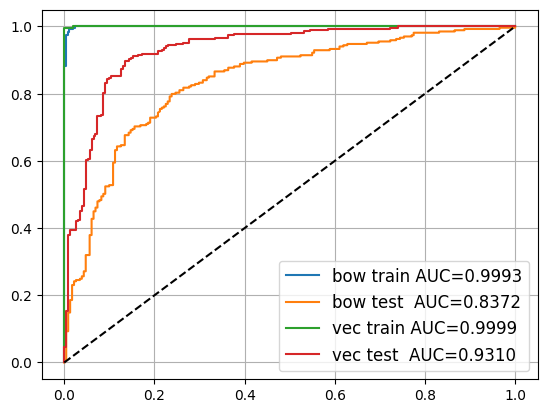

In [143]:
wv_model = LogisticRegression(max_iter=10000).fit(X_train_wv, y_train)

for name, X, y, model in [
    ('bow train', X_train_bow, y_train, bow_model),
    ('bow test ', X_test_bow, y_test, bow_model),
    ('vec train', X_train_wv, y_train, wv_model),
    ('vec test ', X_test_wv, y_test, wv_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

assert roc_auc_score(y_test, wv_model.predict_proba(X_test_wv)[:, 1]) > 0.92, "something's wrong with your features"

If everything went right, you've just managed to reduce misclassification rate by a factor of two.
This trick is very useful when you're dealing with small datasets. However, if you have hundreds of thousands of samples, there's a whole different range of methods for that. We'll get there in the second part.

**Would you like to know more?**
* See what other embeddings are there in the model zoo: `gensim.downloader.info()`
* Take a look at [FastText embeddings](https://github.com/facebookresearch/fastText)